# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [1]:
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/nm47/txs156/"
repobase = "/home/561/rmh561/ML/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

# Import the PartialConv2d layer from om2_model_utils module
from om2_model_utils import PartialConv2d

## Setup PyEarthTools data accessor and pipeline

In [2]:
# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

# Full access pipeline:
full = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  #
    petpipe.operations.xarray.values.FillNan(0),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('2000-06', '2001-01', interval='1 month')
)

ipipe = iter(full)  # Make an iterator to walk the time period
full.exceptions_to_ignore
n = next(ipipe)

# Load land-sea mask:
ds = xr.open_dataset(userbase+"OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
mask_xr = xr.where(np.isnan(ds.total_surface_heat_flx.isel(time=0)),0,1)
mask = mask_xr.values

## Do some checks - input data and partial convolutions

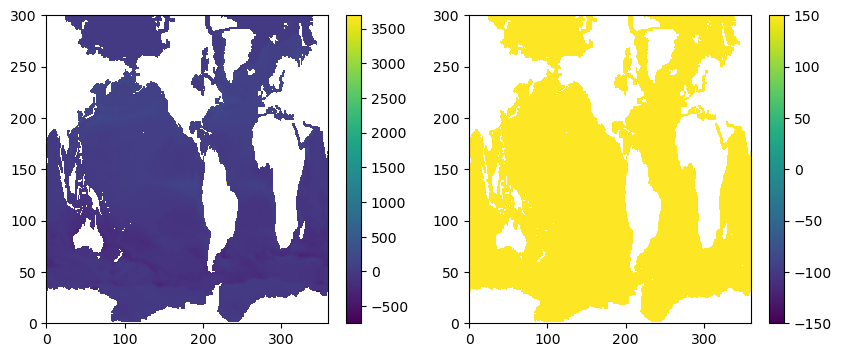

In [3]:
# Quick check to see if things look reasonable:
QNET = np.where(mask, n[0,0,:,:], np.nan)
OHC = np.where(mask, n[0,1,:,:], np.nan)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

pcm0 = axes[0].pcolormesh(OHC)
pcm1 = axes[1].pcolormesh(QNET, vmin=-150, vmax=150)

fig.colorbar(pcm0, ax=axes[0])
fig.colorbar(pcm1, ax=axes[1])

Input shape: torch.Size([1, 1, 300, 360])
Input Mask shape: torch.Size([1, 1, 300, 360])
Output shape: torch.Size([1, 1, 150, 180])
New Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796296296296
New valid fraction: 0.6898888945579529


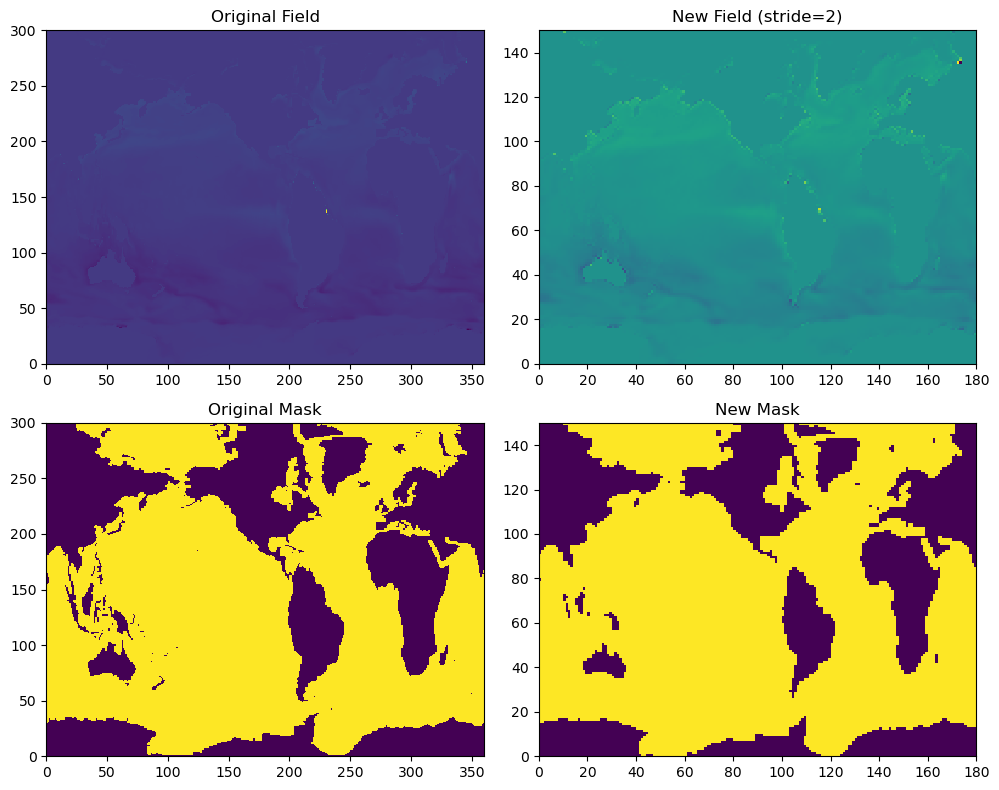

In [4]:
# Test Partial Convolution:
# convert to tensors
field = n[0,1,:,:]  # Take the first variable (OHC) for the first time step
x = torch.tensor(field, dtype=torch.float32)
mask_t = torch.tensor(mask, dtype=torch.float32)  # Explicit .values to extract numpy array
x = x.unsqueeze(0).unsqueeze(0)
mask_t = mask_t.unsqueeze(0).unsqueeze(0)

# Do an example convolution:
layer = PartialConv2d(in_ch=1,out_ch=1,kernel_size=3,stride=2,padding=1)
out, new_mask = layer(x, mask_t)

print("Input shape:", x.shape)
print("Input Mask shape:", mask_t.shape)
print("Output shape:", out.shape)
print("New Mask shape:", new_mask.shape)

# Convert tensors → numpy
new_field = out.detach().squeeze().numpy()
new_mask  = new_mask.detach().squeeze().numpy()

# Fractions covered by ocean:
print("Original valid fraction:", mask.mean().item())
print("New valid fraction:", new_mask.mean().item())

# Plot the results:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
im0 = axes[0,0].pcolormesh(field)
axes[0,0].set_title("Original Field")
im1 = axes[1,0].pcolormesh(mask)
axes[1,0].set_title("Original Mask")
im2 = axes[0,1].pcolormesh(new_field)
axes[0,1].set_title("New Field (stride=2)")
im3 = axes[1,1].pcolormesh(new_mask)
axes[1,1].set_title("New Mask")
plt.tight_layout()
plt.show()

## Define the model

In [5]:
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)
        reconstructed = self.sigmoid(x)
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed

## Initialize model and prepare data for training

In [6]:
# Initialize model and move to device
model = AutoEncoder(input_channel_count=n.shape[1], output_channel_count=n.shape[1]).to(device)

# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Convert numpy -> tensor:
x = torch.from_numpy(n).float().to(device)

# Prepare mask:
#mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).float().to(device)
mask_t = torch.tensor(np.ones_like(mask), dtype=torch.float32).unsqueeze(0).unsqueeze(0).float().to(device) # zero mask for testing

# Normalization ignoring NaNs:
mean = (x*mask_t).mean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
var = torch.mean((x*mask_t - mean) ** 2., dim=(0, 2, 3), keepdim=True)
std = torch.sqrt(var + 1e-6)
x_norm = (x*mask_t - mean) / (std + 1e-6)
#x_norm = torch.nan_to_num(x_norm, nan=0.0)
x_in = x_norm

Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


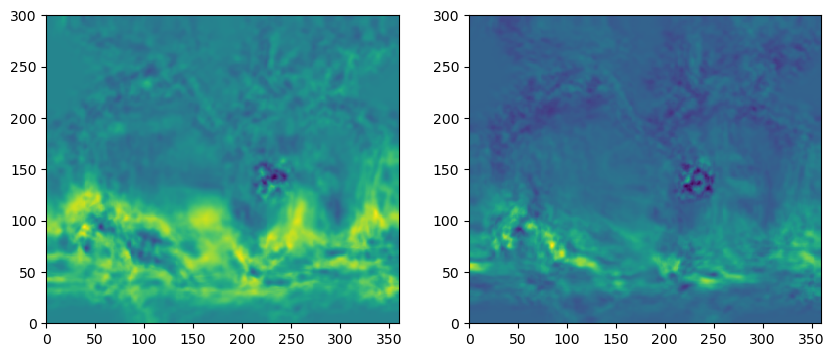

In [7]:
# Test model forward pass with untrained weights:
prediction = model(x_in, mask_t)
print("Input shape:", x_in.shape)
print("Mask shape:", mask_t.shape)
print("Prediction shape:", prediction.shape)

image_numpy_for_display = prediction.to('cpu').detach().numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pcolormesh(image_numpy_for_display[0][0])
axes[1].pcolormesh(image_numpy_for_display[0][1])
plt.show()

## Training loop

In [8]:
%%time

def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    # Training loop
    
    sample_ix = 0 
    
    for epoch in range(num_epochs):
        total_loss = 0    
        epoch_samples = 0
        ipipe = iter(full)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break  # advance the epoch loop
            except:
                pass # some samples are just missing
    
            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   
            mean = x.nanmean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
            var = torch.nanmean((x - mean) ** 2, dim=(0, 2, 3), keepdim=True)
            std = torch.sqrt(var + 1e-6)
            x_norm = (x - mean) / (std + 1e-6)
            x_norm = torch.nan_to_num(x_norm, nan=0.0)

            x_in = x_norm
                
            if debug:
                print("Input")
                print(x_in)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model(x_in, mask_t)
            
            # Compute masked loss
            diff = torch.abs(y - x_in)
            loss = (diff * mask_t).sum() / mask_t.sum()
            
            if debug:
                print("prediction")
                print(y)
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        avg_loss = total_loss / epoch_samples
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')
        epoch_samples = 0  # Reset for next epoch

train(debug=False, num_epochs=100, max_samples=15 * 1000, print_per = 500)

Epoch [1/100], Average Loss: 1.7764
Epoch [2/100], Average Loss: 1.7463
Epoch [3/100], Average Loss: 1.6455
Epoch [4/100], Average Loss: 1.4611
Epoch [5/100], Average Loss: 1.3253
Epoch [6/100], Average Loss: 1.2614
Epoch [7/100], Average Loss: 1.2277
Epoch [8/100], Average Loss: 1.1990
Epoch [9/100], Average Loss: 1.1712
Epoch [10/100], Average Loss: 1.1491
Epoch [11/100], Average Loss: 1.1337
Epoch [12/100], Average Loss: 1.1223
Epoch [13/100], Average Loss: 1.1144
Epoch [14/100], Average Loss: 1.1087
Epoch [15/100], Average Loss: 1.1042
Epoch [16/100], Average Loss: 1.1014
Epoch [17/100], Average Loss: 1.0984
Epoch [18/100], Average Loss: 1.0953
Epoch [19/100], Average Loss: 1.0927
Epoch [20/100], Average Loss: 1.0899
Epoch [21/100], Average Loss: 1.0870
Epoch [22/100], Average Loss: 1.0839
Epoch [23/100], Average Loss: 1.0808
Epoch [24/100], Average Loss: 1.0775
Epoch [25/100], Average Loss: 1.0740
Epoch [26/100], Average Loss: 1.0703
Epoch [27/100], Average Loss: 1.0666
Epoch [28/

## Compute final prediction

In [9]:
prediction = model(x_in, mask_t)

# Convert back to physical units
prediction_phys = prediction[:, :x_norm.shape[1]] * (std + 1e-6) + mean
input_phys = x_in[:, :x_norm.shape[1]] * (std + 1e-6) + mean

# Move to CPU for visualization
prediction_display = prediction_phys.detach().cpu().numpy()
input_display = input_phys.detach().cpu().numpy()

## Diagnostics

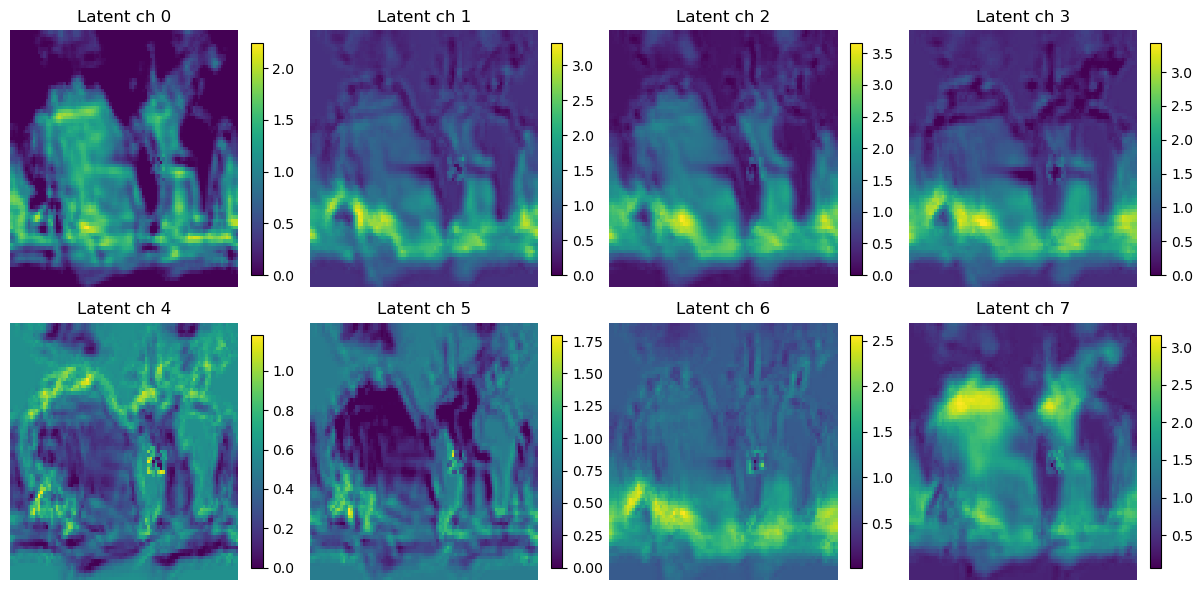

In [10]:
## Inspect Latent Space

latent, latent_mask = model.encode(x_in, mask_t)
z = latent[0].detach().cpu().numpy()  # (C_latent, H_latent, W_latent)

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    if i < z.shape[0]:
        im = ax.pcolormesh(z[i], cmap="viridis")
        ax.set_title(f"Latent ch {i}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [11]:
## Compute RMSE

RMSE = []

ds = xr.open_dataset(userbase+"OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)
area_weighted = area_t * mask

# Compute per-channel error
err1 = prediction_display[0,0] - input_display[0,0]
err2 = prediction_display[0,1] - input_display[0,1]

rmse1 = np.sqrt(np.nansum(err1**2 * area_weighted) / np.nansum(area_weighted))
rmse2 = np.sqrt(np.nansum(err2**2 * area_weighted) / np.nansum(area_weighted))

RMSE.append(rmse2)
RMSE.append(rmse1)

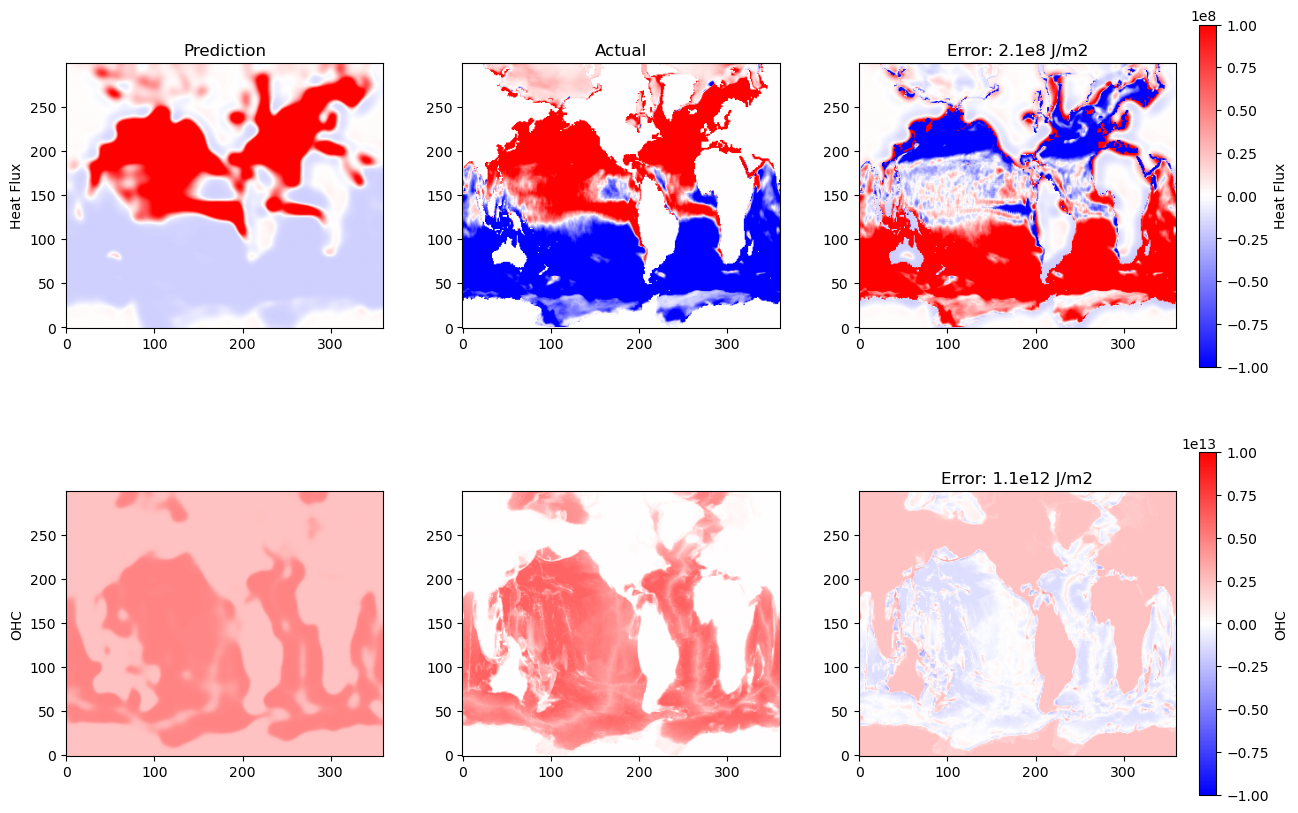

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(30*0.5, 20*0.5))
gs = fig.add_gridspec(2, 3, wspace=0.25, hspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# ---- Row 1: Heat Flux ----
im1 = ax1.imshow(
    prediction_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)
ax2.imshow(
    input_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)
im3 = ax3.imshow(
    prediction_display[0][1]*(30*24*3600) - input_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)

for ax in (ax1, ax2, ax3):
    ax.invert_yaxis()

# ---- Row 2: OHC ----
im4 = ax4.imshow(
    prediction_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)
ax5.imshow(
    input_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)
im6 = ax6.imshow(
    prediction_display[0][0] - input_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)


for ax in (ax4, ax5, ax6):
    ax.invert_yaxis()

# ---- Titles ----
ax1.set_title("Prediction")
ax2.set_title("Actual")
ax3.set_title("Error: {:.1f}e8 J/m2".format(RMSE[0]/1e8*(30*24*3600)))

# ---- Y labels ----
ax1.set_ylabel("Heat Flux")
ax4.set_ylabel("OHC")
ax6.set_title("Error: {:.1f}e12 J/m2".format(RMSE[1]/1e12))

# ---- Colorbars (one per row) ----
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2, ax3],
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar1.set_label("Heat Flux")

cbar2 = fig.colorbar(
    im4,
    ax=[ax4, ax5, ax6],
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar2.set_label("OHC")

plt.show()

In [13]:
OHC_pred_J = (np.nansum(prediction_display[0][0]*area_t, axis=1))
SFX_pred_J = (np.nansum(prediction_display[0][1]*area_t*30*24*3600, axis=1))
OHC_in_J = (np.nansum(input_display[0][0]*area_t, axis=1))
SFX_in_J = (np.nansum(input_display[0][1]*area_t*30*24*3600, axis=1))

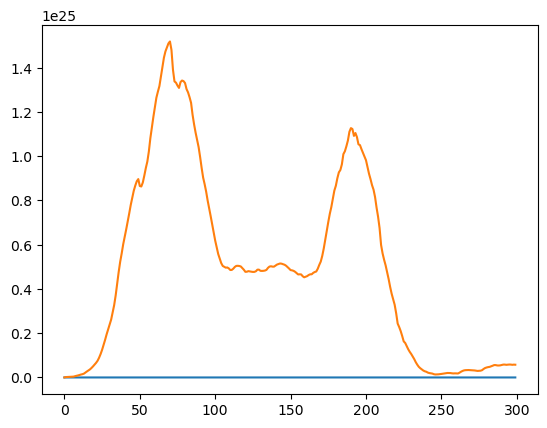

In [14]:
plt.plot(SFX_in_J)
plt.plot(OHC_in_J)